# CS:GO Player Archetype Clustering

Discovering distinct player playstyles from raw CS:GO match statistics using unsupervised learning. Two clustering algorithms — K-Means and Hierarchical Clustering  are compared side by side to identify which better captures natural playstyle groupings among 1805 players.

1: Load & Explore Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/tb_lobby_stats_player.csv')
df.shape

(184152, 38)

In [2]:
df.columns.tolist()

['idLobbyGame',
 'idPlayer',
 'idRoom',
 'qtKill',
 'qtAssist',
 'qtDeath',
 'qtHs',
 'qtBombeDefuse',
 'qtBombePlant',
 'qtTk',
 'qtTkAssist',
 'qt1Kill',
 'qt2Kill',
 'qt3Kill',
 'qt4Kill',
 'qt5Kill',
 'qtPlusKill',
 'qtFirstKill',
 'vlDamage',
 'qtHits',
 'qtShots',
 'qtLastAlive',
 'qtClutchWon',
 'qtRoundsPlayed',
 'descMapName',
 'vlLevel',
 'qtSurvived',
 'qtTrade',
 'qtFlashAssist',
 'qtHitHeadshot',
 'qtHitChest',
 'qtHitStomach',
 'qtHitLeftAtm',
 'qtHitRightArm',
 'qtHitLeftLeg',
 'qtHitRightLeg',
 'flWinner',
 'dtCreatedAt']

In [3]:
df.head()

,idLobbyGame,idPlayer,idRoom,qtKill,qtAssist,qtDeath,qtHs,qtBombeDefuse,qtBombePlant,qtTk,...,qtFlashAssist,qtHitHeadshot,qtHitChest,qtHitStomach,qtHitLeftAtm,qtHitRightArm,qtHitLeftLeg,qtHitRightLeg,flWinner,dtCreatedAt
0,1,1,1,5,1,16,2,0,0,0.0,...,0.0,3.0,13.0,4.0,2.0,2.0,1.0,0.0,0,2022-01-21 19:45:44
1,2,1,2,24,3,18,6,0,4,0.0,...,0.0,7.0,26.0,14.0,2.0,1.0,1.0,3.0,1,2022-02-04 02:09:47
2,3,2,3,6,4,23,2,0,1,0.0,...,0.0,3.0,15.0,8.0,1.0,2.0,0.0,2.0,0,2021-09-18 18:07:43
3,3,391,27508,10,5,20,4,1,0,0.0,...,0.0,6.0,27.0,10.0,1.0,7.0,6.0,6.0,1,2021-09-18 18:07:43
4,4,2,4,8,4,26,6,0,2,0.0,...,2.0,8.0,19.0,12.0,2.0,3.0,2.0,5.0,0,2021-09-27 00:17:45


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184152 entries, 0 to 184151
Data columns (total 38 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   idLobbyGame     184152 non-null  int64  
 1   idPlayer        184152 non-null  int64  
 2   idRoom          184152 non-null  int64  
 3   qtKill          184152 non-null  int64  
 4   qtAssist        184152 non-null  int64  
 5   qtDeath         184152 non-null  int64  
 6   qtHs            184152 non-null  int64  
 7   qtBombeDefuse   184152 non-null  int64  
 8   qtBombePlant    184152 non-null  int64  
 9   qtTk            184032 non-null  float64
 10  qtTkAssist      184032 non-null  float64
 11  qt1Kill         184152 non-null  int64  
 12  qt2Kill         184152 non-null  int64  
 13  qt3Kill         184152 non-null  int64  
 14  qt4Kill         184152 non-null  int64  
 15  qt5Kill         184152 non-null  int64  
 16  qtPlusKill      184152 non-null  int64  
 17  qtFirstKil

In [5]:
df.describe()

,idLobbyGame,idPlayer,idRoom,qtKill,qtAssist,qtDeath,qtHs,qtBombeDefuse,qtBombePlant,qtTk,...,qtTrade,qtFlashAssist,qtHitHeadshot,qtHitChest,qtHitStomach,qtHitLeftAtm,qtHitRightArm,qtHitLeftLeg,qtHitRightLeg,flWinner
count,184152.000000,184152.000000,184152.000000,184152.000000,184152.000000,184152.000000,184152.000000,184152.000000,184152.000000,184032.000000,...,183447.000000,183447.000000,183447.000000,183447.000000,183447.000000,183447.000000,183447.000000,183447.000000,183447.000000,184152.000000
mean,84720.886854,1361.148622,88343.226248,19.113531,3.756033,18.792459,7.640123,0.316054,1.321349,0.022463,...,3.095254,0.570012,9.642889,29.305194,13.525509,1.902511,5.106091,2.265641,2.496509,0.493766
std,49931.048091,784.157397,51564.451107,7.481041,2.205265,5.211614,4.042324,0.575803,1.336699,0.156566,...,1.885027,0.906774,4.769723,11.657993,7.102067,1.650325,2.924184,2.062294,2.162557,0.499962
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41399.750000,676.000000,43742.750000,14.000000,2.000000,16.000000,5.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,6.000000,21.000000,8.000000,1.000000,3.000000,1.000000,1.000000,0.000000
50%,83838.500000,1388.000000,87877.500000,19.000000,4.000000,19.000000,7.000000,0.000000,1.000000,0.000000,...,3.000000,0.000000,9.000000,28.000000,13.000000,2.000000,5.000000,2.000000,2.000000,0.000000
75%,127911.250000,2061.000000,133000.250000,24.000000,5.000000,22.000000,10.000000,1.000000,2.000000,0.000000,...,4.000000,1.000000,12.000000,36.000000,18.000000,3.000000,7.000000,3.000000,4.000000,1.000000
max,172911.000000,2716.000000,178500.000000,85.000000,24.000000,65.000000,41.000000,5.000000,12.000000,12.000000,...,20.000000,14.000000,49.000000,122.000000,77.000000,17.000000,30.000000,21.000000,22.000000,1.000000


In [6]:
df.isnull().sum()

idLobbyGame         0
idPlayer            0
idRoom              0
qtKill              0
qtAssist            0
qtDeath             0
qtHs                0
qtBombeDefuse       0
qtBombePlant        0
qtTk              120
qtTkAssist        120
qt1Kill             0
qt2Kill             0
qt3Kill             0
qt4Kill             0
qt5Kill             0
qtPlusKill          0
qtFirstKill         0
vlDamage            0
qtHits            120
qtShots             0
qtLastAlive       120
qtClutchWon         0
qtRoundsPlayed      0
descMapName         0
vlLevel             0
qtSurvived        705
qtTrade           705
qtFlashAssist     705
qtHitHeadshot     705
qtHitChest        705
qtHitStomach      705
qtHitLeftAtm      705
qtHitRightArm     705
qtHitLeftLeg      705
qtHitRightLeg     705
flWinner            0
dtCreatedAt         0
dtype: int64

In [7]:
player_stats = df.groupby('idPlayer').agg({
    'qtKill': 'mean',
    'qtAssist': 'mean',
    'qtDeath': 'mean',
    'qtHs': 'mean',
    'vlDamage': 'mean',
    'qtBombeDefuse': 'mean',
    'qtBombePlant': 'mean',
    'qtClutchWon': 'mean',
    'qtFlashAssist': 'mean',
    'qtFirstKill': 'mean',
    'qtSurvived': 'mean',
    'qtRoundsPlayed': 'mean',
    'flWinner': 'mean',
    'idLobbyGame': 'count'
}).reset_index()

player_stats.rename(columns={'idLobbyGame': 'matches_played'}, inplace=True)

player_stats.shape

(2469, 15)

In [8]:
player_stats.head()

,idPlayer,qtKill,qtAssist,qtDeath,qtHs,vlDamage,qtBombeDefuse,qtBombePlant,qtClutchWon,qtFlashAssist,qtFirstKill,qtSurvived,qtRoundsPlayed,flWinner,matches_played
0,1,14.500000,2.000000,17.000000,4.000000,1922.000000,0.000000,2.000000,0.500000,0.000000,2.00000,4.500000,22.000000,0.500000,2
1,2,9.714286,3.095238,20.142857,4.095238,1481.380952,0.047619,1.380952,0.000000,0.809524,2.00000,4.190476,24.047619,0.380952,21
2,3,21.348315,3.584270,19.415730,8.292135,2639.921348,0.449438,1.483146,0.415730,0.337079,2.05618,7.426966,27.651685,0.505618,89
3,4,9.666667,1.333333,14.666667,3.666667,1219.333333,0.333333,0.333333,0.333333,0.000000,1.00000,5.333333,20.333333,0.333333,3
4,5,18.000000,4.750000,15.750000,6.750000,2344.500000,0.750000,2.250000,0.500000,0.000000,1.50000,6.500000,22.750000,0.250000,4


In [9]:
player_stats['matches_played'].describe()

count    2469.000000
mean       74.585662
std        98.617952
min         1.000000
25%         8.000000
50%        34.000000
75%       104.000000
max       873.000000
Name: matches_played, dtype: float64

In [10]:
player_stats_filtered = player_stats[player_stats['matches_played'] >= 10].reset_index(drop=True)

player_stats_filtered.shape

(1805, 15)

2: Feature Engineering

In [11]:
df_feat = player_stats_filtered.copy()

df_feat['kda_ratio'] = (df_feat['qtKill'] + df_feat['qtAssist']) / (df_feat['qtDeath'] + 1)
df_feat['headshot_rate'] = df_feat['qtHs'] / (df_feat['qtKill'] + 1)
df_feat['win_rate'] = df_feat['flWinner']
df_feat['entry_aggression'] = df_feat['qtFirstKill'] / df_feat['qtRoundsPlayed']
df_feat['support_score'] = df_feat['qtFlashAssist'] / (df_feat['qtKill'] + 1)
df_feat['objective_score'] = (df_feat['qtBombeDefuse'] + df_feat['qtBombePlant']) / df_feat['qtRoundsPlayed']

df_feat.head()

,idPlayer,qtKill,qtAssist,qtDeath,qtHs,vlDamage,qtBombeDefuse,qtBombePlant,qtClutchWon,qtFlashAssist,...,qtSurvived,qtRoundsPlayed,flWinner,matches_played,kda_ratio,headshot_rate,win_rate,entry_aggression,support_score,objective_score
0,2,9.714286,3.095238,20.142857,4.095238,1481.380952,0.047619,1.380952,0.000000,0.809524,...,4.190476,24.047619,0.380952,21,0.605856,0.382222,0.380952,0.083168,0.075556,0.059406
1,3,21.348315,3.584270,19.415730,8.292135,2639.921348,0.449438,1.483146,0.415730,0.337079,...,7.426966,27.651685,0.505618,89,1.221244,0.371041,0.505618,0.074360,0.015083,0.069890
2,6,21.153846,4.307692,19.846154,8.615385,2779.576923,0.307692,0.730769,0.423077,0.115385,...,6.846154,27.423077,0.538462,26,1.221402,0.388889,0.538462,0.158485,0.005208,0.037868
3,7,12.125000,4.062500,18.500000,5.187500,1858.375000,0.187500,1.812500,0.125000,0.062500,...,5.312500,24.062500,0.437500,16,0.830128,0.395238,0.437500,0.051948,0.004762,0.083117
4,9,22.153846,3.215385,16.907692,10.246154,2720.400000,0.338462,2.584615,0.723077,0.369231,...,8.476923,26.400000,0.553846,65,1.416667,0.442525,0.553846,0.065268,0.015947,0.110723


In [12]:
feature_columns = ['kda_ratio', 'headshot_rate', 'win_rate', 'entry_aggression', 'support_score', 'objective_score']

X = df_feat[feature_columns].copy()

X.describe()

,kda_ratio,headshot_rate,win_rate,entry_aggression,support_score,objective_score
count,1805.000000,1805.000000,1805.000000,1805.000000,1805.000000,1805.000000
mean,1.137817,0.369023,0.491627,0.097492,0.026197,0.062556
std,0.208634,0.065070,0.101504,0.029605,0.015206,0.021198
min,0.400000,0.180734,0.100000,0.013109,0.000000,0.010959
25%,1.021878,0.324427,0.437500,0.077515,0.015773,0.047079
50%,1.135635,0.366601,0.491525,0.096008,0.023609,0.061158
75%,1.255987,0.410506,0.545455,0.116436,0.034025,0.075581
max,2.096525,0.630769,0.944444,0.219697,0.130782,0.151032


3: Preprocessing

In [13]:
X.isnull().sum()

kda_ratio           0
headshot_rate       0
win_rate            0
entry_aggression    0
support_score       0
objective_score     0
dtype: int64

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[-2.55044455,  0.20290756, -1.09065052, -0.48396172,  3.24679171,
        -0.14864149],
       [ 0.39998349,  0.03102313,  0.13787217, -0.78156928, -0.73108552,
         0.34609758],
       [ 0.40074295,  0.30538901,  0.46153051,  2.06078521, -1.38063653,
        -1.16497368],
       [-1.47518881,  0.40299039, -0.53339948, -1.53880616, -1.41000252,
         0.97023875],
       [ 1.33692266,  1.1298937 ,  0.61313889, -1.08876059, -0.67425914,
         2.27290747]])

4A: Finding optimal K for K-Means

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters = k , random_state = 42 , n_init = 10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled , labels)
    silhouette_scores.append(score)

silhouette_scores


[0.17881411752074725,
 0.16138176242027907,
 0.14743470695739902,
 0.15337133801741903,
 0.14298282992414352,
 0.1390664940180775,
 0.1272471785363875,
 0.1282435908532982,
 0.12695679769098805]

In [16]:
X.corr()

,kda_ratio,headshot_rate,win_rate,entry_aggression,support_score,objective_score
kda_ratio,1.000000,0.270151,0.482881,0.607676,-0.038765,0.147614
headshot_rate,0.270151,1.000000,0.124002,0.259854,0.097275,-0.104347
win_rate,0.482881,0.124002,1.000000,0.240798,0.038145,0.132596
entry_aggression,0.607676,0.259854,0.240798,1.000000,-0.129540,-0.242212
support_score,-0.038765,0.097275,0.038145,-0.129540,1.000000,0.159614
objective_score,0.147614,-0.104347,0.132596,-0.242212,0.159614,1.000000


4B: Running K-Means and naming clusters

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_feat["kmeans_cluster"] = kmeans_labels

df_feat["kmeans_cluster"].value_counts()

kmeans_cluster
2    660
1    500
0    360
3    285
Name: count, dtype: int64

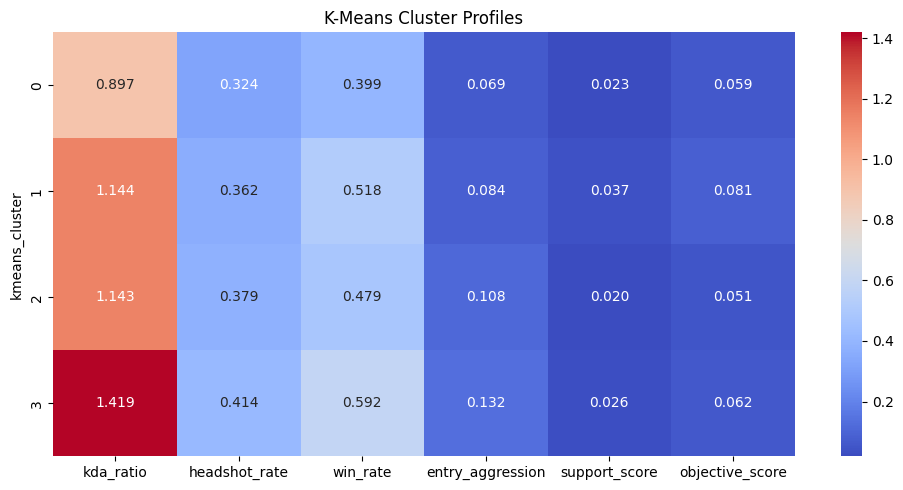

In [18]:
cluster_profiles = df_feat.groupby("kmeans_cluster")[feature_columns].mean()

plt.figure(figsize=(10,5))

sns.heatmap(cluster_profiles, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('K-Means Cluster Profiles')
plt.xticks(rotation = 0 , ha = 'center')
plt.tight_layout()
plt.show()

In [19]:
cluster_names = {
    0: 'Passive/Low Impact',
    1: 'Balanced Contributor',
    2: 'Balanced Aggressor',
    3: 'Dominant Fragger'
}

df_feat['archetype'] = df_feat['kmeans_cluster'].map(cluster_names)

df_feat[['idPlayer', 'kmeans_cluster', 'archetype']].head()

,idPlayer,kmeans_cluster,archetype
0,2,0,Passive/Low Impact
1,3,2,Balanced Aggressor
2,6,2,Balanced Aggressor
3,7,0,Passive/Low Impact
4,9,1,Balanced Contributor


4C: Running Hierarchical Clustering and dendrogram

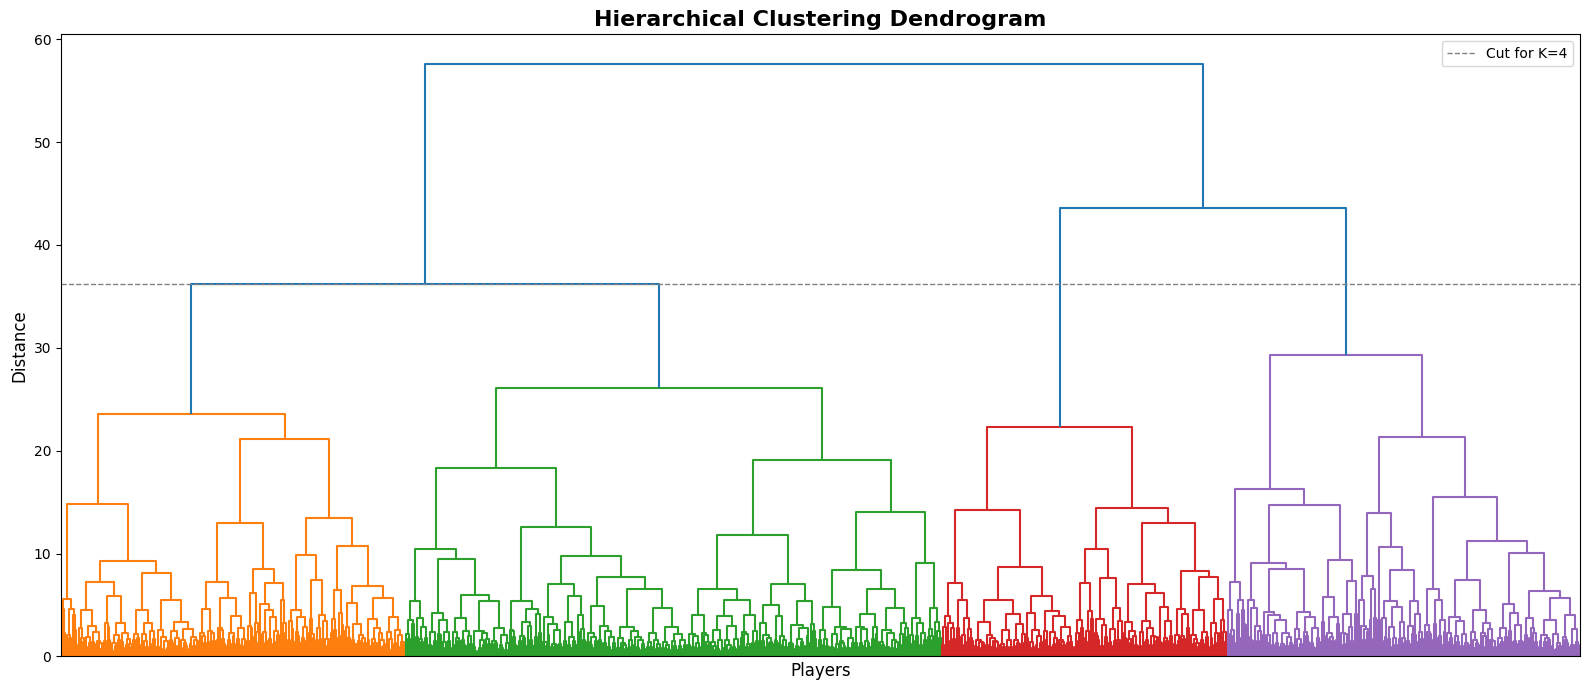

In [20]:
from scipy.cluster.hierarchy import linkage , dendrogram

linkage_matrix = linkage(X_scaled , method = "ward")

plt.figure(figsize=(16, 7))
dendrogram(linkage_matrix, no_labels=True, color_threshold=linkage_matrix[-3, 2])
plt.title('Hierarchical Clustering Dendrogram', fontsize=16, fontweight='bold')
plt.xlabel('Players', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=linkage_matrix[-3, 2], color='gray', linestyle='--', linewidth=1, label='Cut for K=4')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(linkage_matrix , 4 , criterion = "maxclust")

df_feat['hierarchical_cluster'] = hierarchical_labels - 1

df_feat['hierarchical_cluster'].value_counts()

hierarchical_cluster
1    638
3    419
0    409
2    339
Name: count, dtype: int64

5: Algorithm Comparison

In [22]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled , df_feat["kmeans_cluster"])
hierarchical_score = silhouette_score(X_scaled, df_feat['hierarchical_cluster'])

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hierarchical_score)

K-Means Silhouette Score: 0.14743470695739902
Hierarchical Silhouette Score: 0.0826664384745531


In [23]:
pd.crosstab(df_feat['kmeans_cluster'], df_feat['hierarchical_cluster'])

hierarchical_cluster,0,1,2,3
kmeans_cluster,,,,
0,0,39,268,53
1,28,115,19,338
2,140,455,52,13
3,241,29,0,15


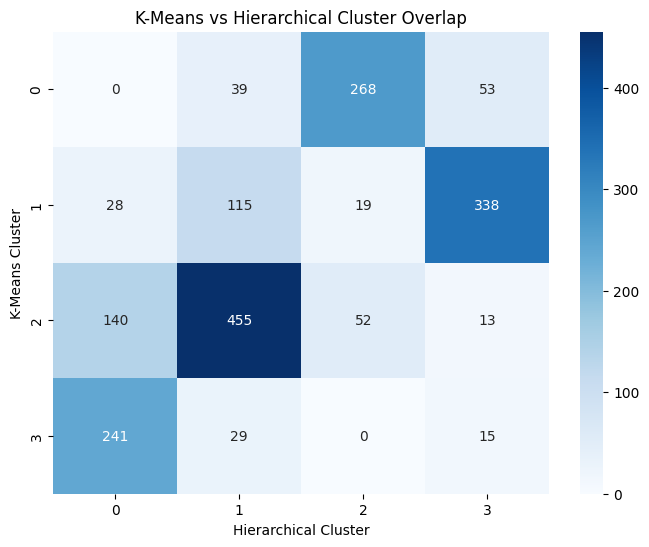

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(pd.crosstab(df_feat['kmeans_cluster'], df_feat['hierarchical_cluster']), annot=True, fmt='d', cmap='Blues')
plt.title('K-Means vs Hierarchical Cluster Overlap')
plt.xlabel('Hierarchical Cluster')
plt.ylabel('K-Means Cluster')
plt.xticks(rotation=0)
plt.show()

6: Visualization By PCA Plot

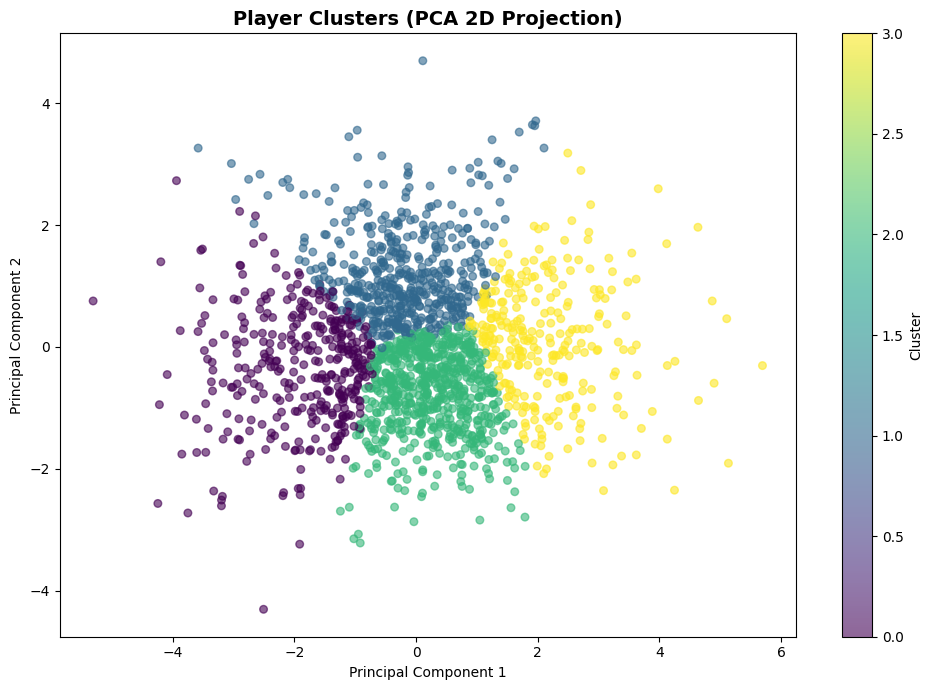

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_feat['kmeans_cluster'], cmap='viridis', s=30, alpha=0.6)
plt.title('Player Clusters (PCA 2D Projection)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.savefig('outputs/kmeans_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

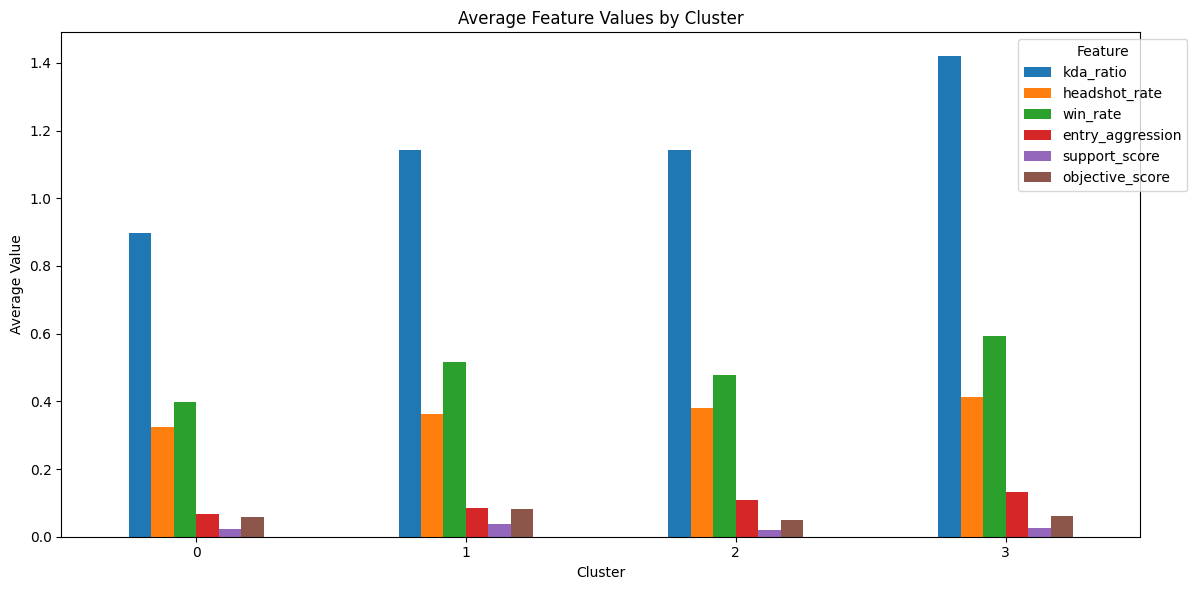

In [26]:
cluster_means = df_feat.groupby('kmeans_cluster')[feature_columns].mean()

cluster_means.plot(kind='bar', figsize=(12, 6))
plt.title('Average Feature Values by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('outputs/kmeans_bar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

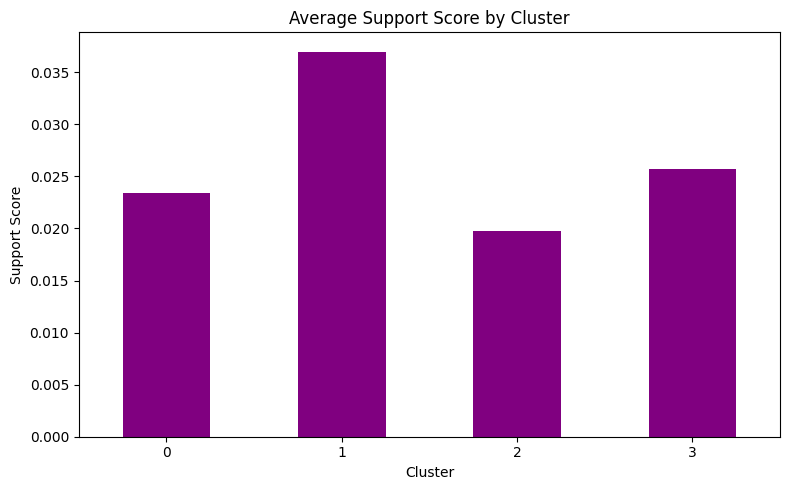

In [27]:
cluster_means = df_feat.groupby('kmeans_cluster')[feature_columns].mean()

cluster_means['support_score'].plot(kind='bar', figsize=(8, 5), color='purple')
plt.title('Average Support Score by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Support Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/support_score_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

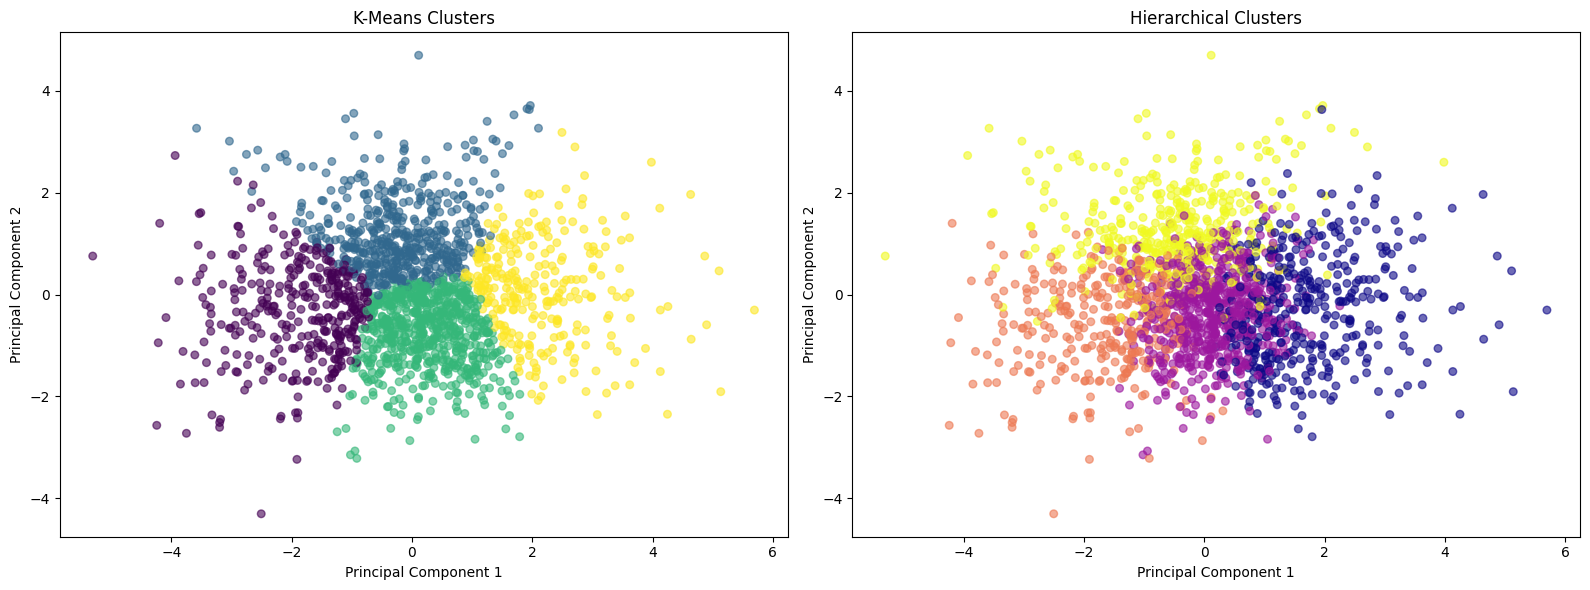

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_feat['kmeans_cluster'], cmap='viridis', s=30, alpha=0.6)
axes[0].set_title('K-Means Clusters')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df_feat['hierarchical_cluster'], cmap='plasma', s=30, alpha=0.6)
axes[1].set_title('Hierarchical Clusters')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.savefig('outputs/algorithm_comparison_pca.png', dpi=300, bbox_inches='tight')
plt.show()

7: Final Results 

In [32]:
cluster_names = {
    0: 'Passive/Low Impact',
    1: 'Support/Utility Player',
    2: 'Balanced Aggressor',
    3: 'Dominant Fragger'
}

df_feat['archetype'] = df_feat['kmeans_cluster'].map(cluster_names)

results = df_feat[['idPlayer', 'kmeans_cluster', 'archetype', 'hierarchical_cluster'] + feature_columns]
results.to_csv('data/processed/clustering_results.csv', index=False)

results.head()
 

,idPlayer,kmeans_cluster,archetype,hierarchical_cluster,kda_ratio,headshot_rate,win_rate,entry_aggression,support_score,objective_score
0,2,0,Passive/Low Impact,3,0.605856,0.382222,0.380952,0.083168,0.075556,0.059406
1,3,2,Balanced Aggressor,1,1.221244,0.371041,0.505618,0.074360,0.015083,0.069890
2,6,2,Balanced Aggressor,0,1.221402,0.388889,0.538462,0.158485,0.005208,0.037868
3,7,0,Passive/Low Impact,2,0.830128,0.395238,0.437500,0.051948,0.004762,0.083117
4,9,1,Support/Utility Player,3,1.416667,0.442525,0.553846,0.065268,0.015947,0.110723


In [30]:
results = df_feat[['idPlayer', 'kmeans_cluster', 'archetype', 'hierarchical_cluster'] + feature_columns]

results.to_csv('data/processed/clustering_results.csv', index=False)

results.head()

,idPlayer,kmeans_cluster,archetype,hierarchical_cluster,kda_ratio,headshot_rate,win_rate,entry_aggression,support_score,objective_score
0,2,0,Passive/Low Impact,3,0.605856,0.382222,0.380952,0.083168,0.075556,0.059406
1,3,2,Balanced Aggressor,1,1.221244,0.371041,0.505618,0.074360,0.015083,0.069890
2,6,2,Balanced Aggressor,0,1.221402,0.388889,0.538462,0.158485,0.005208,0.037868
3,7,0,Passive/Low Impact,2,0.830128,0.395238,0.437500,0.051948,0.004762,0.083117
4,9,1,Support/Utility Player,3,1.416667,0.442525,0.553846,0.065268,0.015947,0.110723


## Insights and Conclusions

### What this project does
I wanted to see if I could find natural player types in CS:GO just from match stats, without any labels telling me what "type" a player is. Used data from the Gamers Club platform, starting with 184,152 individual match rows. I grouped these by player and kept only players with 10+ matches (1,805 players total) so the averages would actually mean something. From there I built 6 features that try to capture playstyle rather than just raw stats: kda_ratio, headshot_rate, win_rate, entry_aggression, support_score, and objective_score.

### Comparing K-Means and Hierarchical
I ran both algorithms with K=4, picked using Silhouette Score testing from K=2 to K=10. K-Means came out ahead, scoring 0.147 versus 0.083 for Hierarchical. You can actually see this in the PCA plots too. K-Means draws pretty clean boundaries between groups, while Hierarchical's clusters blend into each other a lot more.

What I found interesting though was checking how much the two algorithms actually agreed with each other using a crosstab. They matched really well on the top-performing cluster, with 85% of the same players landing in both algorithms' "best" group. But for the middle-performing players, the two methods disagreed a lot more. That tells me the best players are genuinely distinct, but average players don't really fall into one clean box since their stats overlap heavily.

### Why I went with K-Means
Higher silhouette score and cleaner separation in the PCA plot made it the more defensible choice objectively. I still kept the Hierarchical dendrogram in the project though, since it backs up that the top cluster is real, having been found independently by a completely different method.

### The 4 player types I found
The first group, which I called Dominant Fragger, is clearly the strongest: highest KDA, win rate, and aggression, and the easiest cluster to separate from the rest. The second, Balanced Aggressor, is solid across the board with nothing particularly standout. The third one, Support/Utility Player, I almost missed. Looking at just the cluster averages, it looked like a plain "medium" cluster. But when I broke it down feature by feature using box plots, this group actually had the highest support_score of all 4 clusters, meaning they aren't average performers, they're just playing a different role by helping teammates rather than getting kills themselves. The last group, Passive/Low Impact, scored lowest across most metrics and seemed less involved in fights overall.

### Being honest about the limitations
The silhouette scores weren't great, with 0.147 being moderate at best and nowhere near a "perfect" clustering result. I think that's just how this kind of data is. Casual and ranked players don't stick to one fixed role match after match the way pros might. Someone could play aggressive one game and passive the next depending on their team. So the clusters found here represent general tendencies rather than strict categories.

### What I'd try next
Adding map-specific stats or weapon preference could sharpen the groups further. DBSCAN or Gaussian Mixture Models might also handle this kind of blended, overlapping data better than K-Means does. Comparing against pro or semi-pro player data, who probably stick to defined roles more consistently, could also be interesting to see if the clusters come out sharper.